In [2]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian

from koala.graph_color import vertex_color
from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)

from dimer_models.lattice_generation import expand_edges_to_squares
from dimer_models.kasteleyn import (
    kasteleyn_matrix,
    find_kasteleyn_number,
    find_local_dimer_probability,
)

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from copy import copy

In [3]:
def monomer_corr(lattice, verts):
    monomer_lattice = gu.remove_vertices(lattice, verts)
    monomer_prob = find_kasteleyn_number(monomer_lattice, True)
    normalisation = find_kasteleyn_number(lattice, True)
    p = (monomer_prob[0] / normalisation[0]) * 10 ** (
        monomer_prob[1] - normalisation[1]
    )
    return p

60


<Axes: >

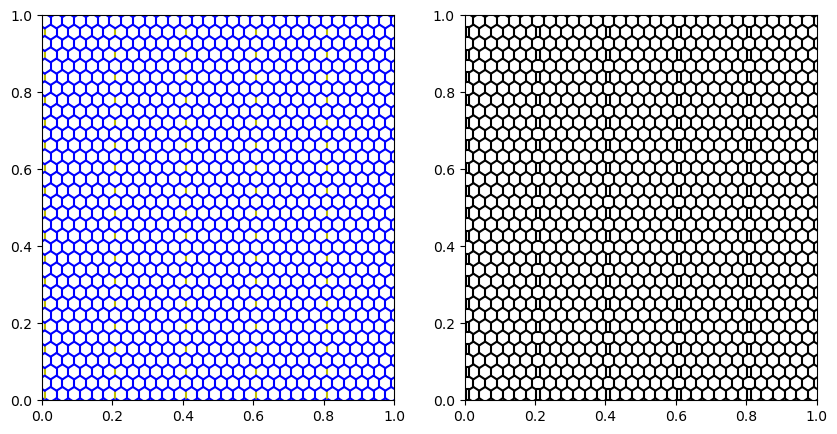

In [4]:
n = 30
every_other = 12  # Width of the strip around the center
options_to_check = 5

center = 0.5 + 1 / (4 * n)
lattice = eg.honeycomb_lattice(n)
edge_centers = np.mean(lattice.vertices.positions[lattice.edges.indices], axis=1)

# kitaev edge labels
edge_angles = np.arctan2(*lattice.edges.vectors.T) % np.pi
_, edge_labels = np.unique(np.round(edge_angles, 2), return_inverse=True)

# Create a mask for edges that are chosen
vert_edge_centers = edge_centers[edge_labels == 0]
_, edge_column = np.unique(vert_edge_centers[:, 0], return_inverse=True)
print(len(_))

mask = np.zeros(lattice.n_edges, dtype=bool)
mask[edge_labels == 0] = edge_column % every_other == 0
mask = mask * (edge_labels == 0)  # Only keep edges with label 0
l2 = expand_edges_to_squares(lattice, np.where(mask)[0])
# l2 = gu.com_relaxation(l2)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
pl.plot_edges(lattice, labels=mask, ax=ax[0], color_scheme=["b", "y", "b"])
pl.plot_edges(l2, ax=ax[1])

In [5]:
# Find the vertex indices for v1 and list of v2 options
v1 = np.argmin(la.norm(l2.vertices.positions - np.array([center, 0.5]), axis=1))
distances_matrix = gu.distance_matrix(l2)[v1]
pos_messed = l2.vertices.positions + 10 * (1 - distances_matrix[:, None] % 2)


v2_options_horizontal = np.array(
    [
        np.argsort(la.norm(pos_messed - np.array([(center - u) % 1, 0.5]), axis=1))[
            :options_to_check
        ]
        for u in np.linspace(0, 0.5, 2 * n)
    ]
)
v2_options_horizontal = np.unique(v2_options_horizontal)
distances_horizontal = distances_matrix[v2_options_horizontal]

v2_options_vertical = np.array(
    [
        np.argsort(la.norm(pos_messed - np.array([(center) % 1, 0.5 + u]), axis=1))[
            :options_to_check
        ]
        for u in np.linspace(0, 0.5, 2 * n)
    ]
)
v2_options_vertical = np.unique(v2_options_vertical.flatten())
distances_vertical = distances_matrix[v2_options_vertical]

# Find the Kasteleyn probabilitiesfor the lattice
dimer_probs = find_local_dimer_probability(l2)

# find probabilities for monomers
monomer_probs_hor = []
for v2 in tqdm(v2_options_horizontal):
    p = monomer_corr(l2, [v1, v2])
    monomer_probs_hor.append(p)

monomer_probs_vert = []
for v2 in tqdm(v2_options_vertical):
    p = monomer_corr(l2, [v1, v2])
    monomer_probs_vert.append(p)


monomer_probs_hor = np.array(monomer_probs_hor)[np.argsort(distances_horizontal)]
monomer_probs_vert = np.array(monomer_probs_vert)[np.argsort(distances_vertical)]

distances_vertical = np.sort(distances_vertical)
distances_horizontal = np.sort(distances_horizontal)


results = {
    "lattice": l2,
    "v1": v1,
    "probs": dimer_probs,
    "v2_options_horizontal": v2_options_horizontal,
    "distances_horizontal": distances_horizontal,
    "monomer_probs_hor": monomer_probs_hor,
    "v2_options_vertical": v2_options_vertical,
    "distances_vertical": distances_vertical,
    "monomer_probs_vert": monomer_probs_vert,
}

100%|██████████| 46/46 [00:42<00:00,  1.08it/s]


3315


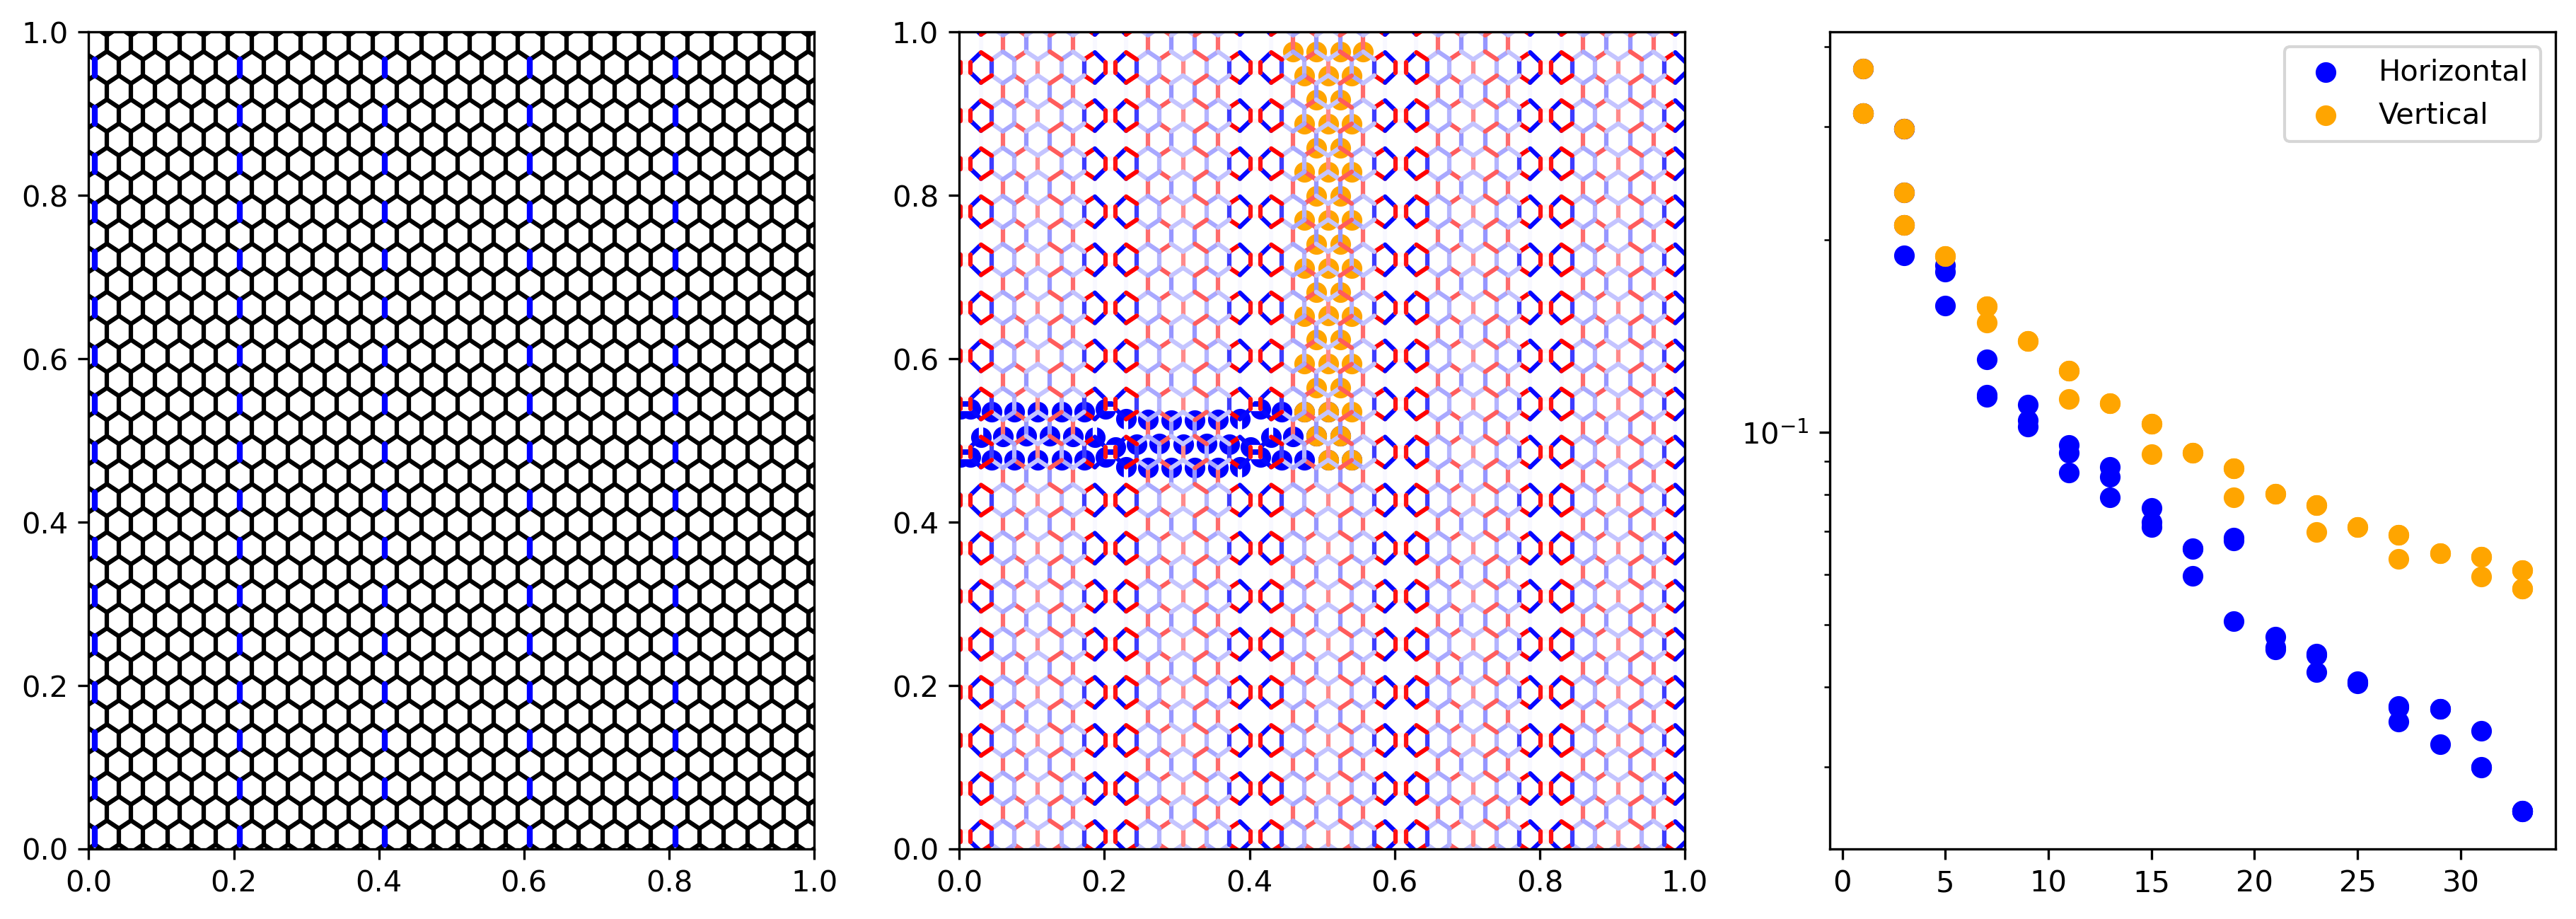

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), dpi=300)
pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(
    lattice,
    subset=np.where(mask),
    ax=ax[0],
    color_scheme=["b", "y", "b"],
    linewidth=2,
)

probs = dimer_probs - (1 / 3)
probs = (
    0.5 * probs / np.max([np.max(np.abs(probs)), 0.01])
)  # Normalize to range [-1, 1]
# print(dimer_probs)

edge_labels = np.arange(l2.n_edges)
cmap = plt.get_cmap("bwr")
color_scheme = cmap(probs + 0.5)  # Shift to center around 0

print(len(color_scheme))
l2s = gu.com_relaxation(l2)
pl.plot_edges(
    l2s,
    ax=ax[1],
    labels=edge_labels,
    color_scheme=color_scheme,
)

ax[1].scatter(*l2s.vertices.positions[[*v2_options_horizontal]].T, color="Blue")
ax[1].scatter(*l2s.vertices.positions[[*v2_options_vertical]].T, color="orange")

ax[2].scatter(distances_horizontal, monomer_probs_hor, label="Horizontal", color="Blue")
ax[2].scatter(distances_vertical, monomer_probs_vert, label="Vertical", color="orange")
ax[2].legend()

ax[2].set_yscale("log")

plt.savefig("strip_density_example.png", dpi=300)